# Notebook 2: Decision Tree From Scratch
## Cài đặt thuật toán cây quyết định từ đầu (không dùng sklearn)

**Mục tiêu:**
- Chứng minh hiểu sâu thuật toán Decision Tree
- Implement Hunt's Algorithm với GINI Index và Entropy
- Đánh giá trên Bank Marketing dataset


In [1]:
# ====== SETUP CHO JUPYTER LOCAL ======
import os, sys

# Thư mục hiện tại: jupyter/
JUPYTER_DIR = os.path.dirname(os.path.abspath('__file__'))
os.chdir(JUPYTER_DIR)

# Thêm thư mục gốc project vào sys.path (để import src/)
PROJECT_DIR = os.path.abspath('..')
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

# Tạo thư mục output nếu chưa có
os.makedirs('data', exist_ok=True)
os.makedirs('report', exist_ok=True)

print(f'Jupyter dir: {JUPYTER_DIR}')
print(f'Project dir: {PROJECT_DIR}')
print(f'src/ available: {os.path.exists(os.path.join(PROJECT_DIR, "src"))}')
print('✅ Setup complete!')


Jupyter dir: /home/thacbao/Documents/project/kpdl/jupyter
Project dir: /home/thacbao/Documents/project/kpdl
src/ available: True
✅ Setup complete!


In [2]:
import numpy as np
import pandas as pd
import pickle
import time
import sys
import matplotlib.pyplot as plt
# sys.path already set in setup cell

from src.tree import DecisionTreeClassifier
from src.criteria import gini_index, entropy, information_gain, gain_ratio
from src.metrics import accuracy, precision, recall, f1_score, confusion_matrix, classification_report
from src.visualizer import plot_confusion_matrix, plot_feature_importance, plot_accuracy_vs_depth

print("Modules loaded successfully.")


Modules loaded successfully.


## 1. Load dữ liệu đã tiền xử lý


In [3]:
# Load processed data
with open("data/processed_data.pkl", "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
feature_names = data["feature_names"]

print(f"Train: {X_train.shape[0]:,} mẫu × {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]:,} mẫu × {X_test.shape[1]} features")


Train: 32,940 mẫu × 63 features
Test:  8,236 mẫu × 63 features


## 2. Minh họa Criteria — Tính tay để verify code

### 2.1 GINI Index


In [4]:
# Minh họa: tính GINI bằng tay
print("=== GINI Index ===")
print("Công thức: GINI(t) = 1 - Σ [p(i|t)]²")
print()

# Case 1: pure node
y_pure = ["yes", "yes", "yes", "yes"]
print(f"Node pure [yes,yes,yes,yes]:")
print(f"  p(yes) = 4/4 = 1.0")
print(f"  GINI = 1 - 1.0² = 0.0")
print(f"  Code: {gini_index(y_pure):.4f} ✓")
print()

# Case 2: mixed
y_mixed = ["yes", "yes", "no", "no", "no", "no"]
print(f"Node mixed [yes,yes,no,no,no,no]:")
print(f"  p(yes) = 2/6 = 0.333")
print(f"  p(no)  = 4/6 = 0.667")
print(f"  GINI = 1 - 0.333² - 0.667² = 1 - 0.111 - 0.444 = 0.444")
print(f"  Code: {gini_index(y_mixed):.4f} ✓")


=== GINI Index ===
Công thức: GINI(t) = 1 - Σ [p(i|t)]²

Node pure [yes,yes,yes,yes]:
  p(yes) = 4/4 = 1.0
  GINI = 1 - 1.0² = 0.0
  Code: 0.0000 ✓

Node mixed [yes,yes,no,no,no,no]:
  p(yes) = 2/6 = 0.333
  p(no)  = 4/6 = 0.667
  GINI = 1 - 0.333² - 0.667² = 1 - 0.111 - 0.444 = 0.444
  Code: 0.4444 ✓


In [5]:
# Minh họa: Entropy
print("=== Entropy ===")
print("Công thức: Entropy(t) = -Σ p(i|t) × log₂(p(i|t))")
print()

y_mixed = ["yes", "yes", "no", "no", "no", "no"]
print(f"Node [yes,yes,no,no,no,no]:")
print(f"  p(yes) = 2/6 = 0.333")
print(f"  p(no)  = 4/6 = 0.667")
import math
ent = -(2/6)*math.log2(2/6) - (4/6)*math.log2(4/6)
print(f"  Entropy = -0.333×log₂(0.333) - 0.667×log₂(0.667) = {ent:.4f}")
print(f"  Code: {entropy(y_mixed):.4f} ✓")
print()

# Information Gain
print("=== Information Gain ===")
print("Công thức: IG = Entropy(parent) - Σ(nᵢ/n) × Entropy(childᵢ)")
y_parent = ["yes"]*3 + ["no"]*3
y_children = [["yes"]*3, ["no"]*3]
ig = information_gain(y_parent, y_children)
print(f"Perfect split: IG = {ig:.4f} (expect 1.0) ✓")


=== Entropy ===
Công thức: Entropy(t) = -Σ p(i|t) × log₂(p(i|t))

Node [yes,yes,no,no,no,no]:
  p(yes) = 2/6 = 0.333
  p(no)  = 4/6 = 0.667
  Entropy = -0.333×log₂(0.333) - 0.667×log₂(0.667) = 0.9183
  Code: 0.9183 ✓

=== Information Gain ===
Công thức: IG = Entropy(parent) - Σ(nᵢ/n) × Entropy(childᵢ)
Perfect split: IG = 1.0000 (expect 1.0) ✓


## 3. Huấn luyện mô hình — GINI criterion


In [6]:
# Train với GINI, max_depth=5
print("=== Training: GINI, max_depth=5 ===")
t0 = time.time()
dt_gini = DecisionTreeClassifier(criterion="gini", max_depth=5)
dt_gini.fit(X_train, y_train, feature_names=feature_names)
t_train = time.time() - t0

print(f"Training time: {t_train:.2f}s")
print(f"Tree depth: {dt_gini.get_depth()}")
print(f"Number of leaves: {dt_gini.get_n_leaves()}")
print(f"Cấu trúc cây (3 levels đầu):")
dt_gini.print_tree()


=== Training: GINI, max_depth=5 ===
Training time: 9.15s
Tree depth: 5
Number of leaves: 31
Cấu trúc cây (3 levels đầu):
nr.employed <= 5087.6500 (samples=32940, gain=0.0297)
├── True:
│   duration <= 162.5000 (samples=3987, gain=0.0912)
│   ├── True:
│   │   pdays <= 6.5000 (samples=1427, gain=0.0156)
│   │   ├── True:
│   │   │   campaign <= 3.5000 (samples=189, gain=0.0268)
│   │   │   ├── True:
│   │   │   │   day_of_week_mon <= 0.5000 (samples=173, gain=0.0261)
│   │   │   │   ├── True:
│   │   │   │   │   → [no] (samples=131, dist={'no': 68, 'yes': 63})
│   │   │   │   └── False:
│   │   │   │       → [no] (samples=42, dist={'no': 33, 'yes': 9})
│   │   │   └── False:
│   │   │       → [no] (samples=16, dist={'no': 16})
│   │   └── False:
│   │       duration <= 123.5000 (samples=1238, gain=0.0112)
│   │       ├── True:
│   │       │   duration <= 77.5000 (samples=807, gain=0.0039)
│   │       │   ├── True:
│   │       │   │   → [no] (samples=311, dist={'no': 308, 'yes': 3})
│   

In [7]:
# Predict + Evaluate
t0 = time.time()
y_pred_gini = dt_gini.predict(X_test)
t_pred = time.time() - t0

print(f"Prediction time: {t_pred:.2f}s")
print(f"=== Classification Report (GINI, depth=5) ===")
report, report_text = classification_report(y_test, y_pred_gini)
print(report_text)


Prediction time: 0.01s
=== Classification Report (GINI, depth=5) ===
                 precision     recall   f1-score    support
-------------------------------------------------------
             no     0.9397     0.9655     0.9524       7308
            yes     0.6534     0.5119     0.5740        928
-------------------------------------------------------
       accuracy                           0.9144       8236



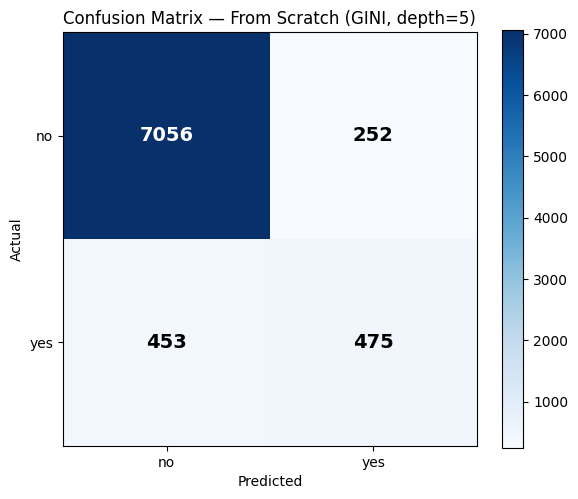

In [8]:
# Confusion Matrix
fig = plot_confusion_matrix(y_test, y_pred_gini, title="Confusion Matrix — From Scratch (GINI, depth=5)")
plt.savefig("report/fig_scratch_cm_gini.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Huấn luyện mô hình — Entropy criterion


In [9]:
# Train với Entropy, max_depth=5
print("=== Training: Entropy, max_depth=5 ===")
t0 = time.time()
dt_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=5)
dt_entropy.fit(X_train, y_train, feature_names=feature_names)
t_train = time.time() - t0

y_pred_entropy = dt_entropy.predict(X_test)

print(f"Training time: {t_train:.2f}s")
print(f"=== Classification Report (Entropy, depth=5) ===")
report_e, report_text_e = classification_report(y_test, y_pred_entropy)
print(report_text_e)


=== Training: Entropy, max_depth=5 ===
Training time: 8.97s
=== Classification Report (Entropy, depth=5) ===
                 precision     recall   f1-score    support
-------------------------------------------------------
             no     0.9396     0.9643     0.9518       7308
            yes     0.6454     0.5119     0.5709        928
-------------------------------------------------------
       accuracy                           0.9133       8236



## 5. So sánh GINI vs Entropy


In [10]:
# So sánh GINI vs Entropy
print("=== So sánh GINI vs Entropy (max_depth=5) ===")
print(f"{'Metric':<15s} {'GINI':>10s} {'Entropy':>10s}")
print("-" * 35)
for metric_name, fn in [("Accuracy", accuracy), ("Precision", precision), ("Recall", recall), ("F1-Score", f1_score)]:
    g = fn(y_test, y_pred_gini, "yes") if metric_name != "Accuracy" else fn(y_test, y_pred_gini)
    e = fn(y_test, y_pred_entropy, "yes") if metric_name != "Accuracy" else fn(y_test, y_pred_entropy)
    print(f"{metric_name:<15s} {g:>10.4f} {e:>10.4f}")


=== So sánh GINI vs Entropy (max_depth=5) ===
Metric                GINI    Entropy
-----------------------------------
Accuracy            0.9144     0.9133
Precision           0.6534     0.6454
Recall              0.5119     0.5119
F1-Score            0.5740     0.5709


## 6. Phân tích Overfitting — Accuracy vs Max Depth


max_depth=    2: train=0.9029, test=0.9046, actual_depth=2, leaves=4
max_depth=    3: train=0.9080, test=0.9094, actual_depth=3, leaves=8
max_depth=    4: train=0.9141, test=0.9116, actual_depth=4, leaves=16
max_depth=    5: train=0.9173, test=0.9144, actual_depth=5, leaves=31
max_depth=    7: train=0.9236, test=0.9165, actual_depth=7, leaves=111
max_depth=   10: train=0.9378, test=0.9095, actual_depth=10, leaves=420
max_depth=   15: train=0.9730, test=0.8979, actual_depth=15, leaves=1404
max_depth=   20: train=0.9959, test=0.8906, actual_depth=20, leaves=2193
max_depth= None: train=1.0000, test=0.8905, actual_depth=28, leaves=2339


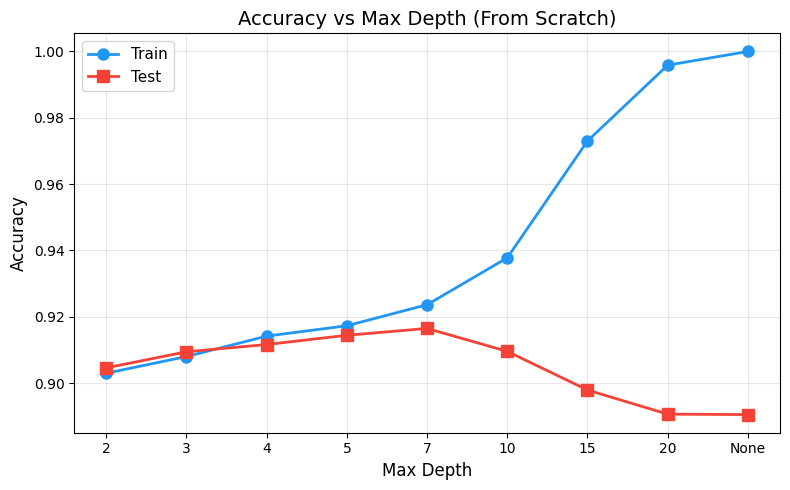

→ Nhận xét: Khi max_depth tăng, train accuracy tăng nhưng test accuracy có thể giảm → Overfitting


In [11]:
# Test nhiều max_depth
depths = [2, 3, 4, 5, 7, 10, 15, 20, None]
train_accs = []
test_accs = []
results = []

for d in depths:
    dt = DecisionTreeClassifier(criterion="gini", max_depth=d)
    dt.fit(X_train, y_train, feature_names=feature_names)

    train_acc = accuracy(y_train, dt.predict(X_train))
    test_acc = accuracy(y_test, dt.predict(X_test))
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    depth_label = str(d) if d else "None"
    results.append({"max_depth": depth_label, "train_acc": train_acc, "test_acc": test_acc,
                    "depth": dt.get_depth(), "leaves": dt.get_n_leaves()})
    print(f"max_depth={depth_label:>5s}: train={train_acc:.4f}, test={test_acc:.4f}, "
          f"actual_depth={dt.get_depth()}, leaves={dt.get_n_leaves()}")

# Plot
depth_labels = [str(d) if d else "None" for d in depths]
fig = plot_accuracy_vs_depth(range(len(depths)), train_accs, test_accs,
                              title="Accuracy vs Max Depth (From Scratch)")
plt.xticks(range(len(depths)), depth_labels)
plt.savefig("report/fig_scratch_depth_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("→ Nhận xét: Khi max_depth tăng, train accuracy tăng nhưng test accuracy có thể giảm → Overfitting")


## 7. Feature Importance


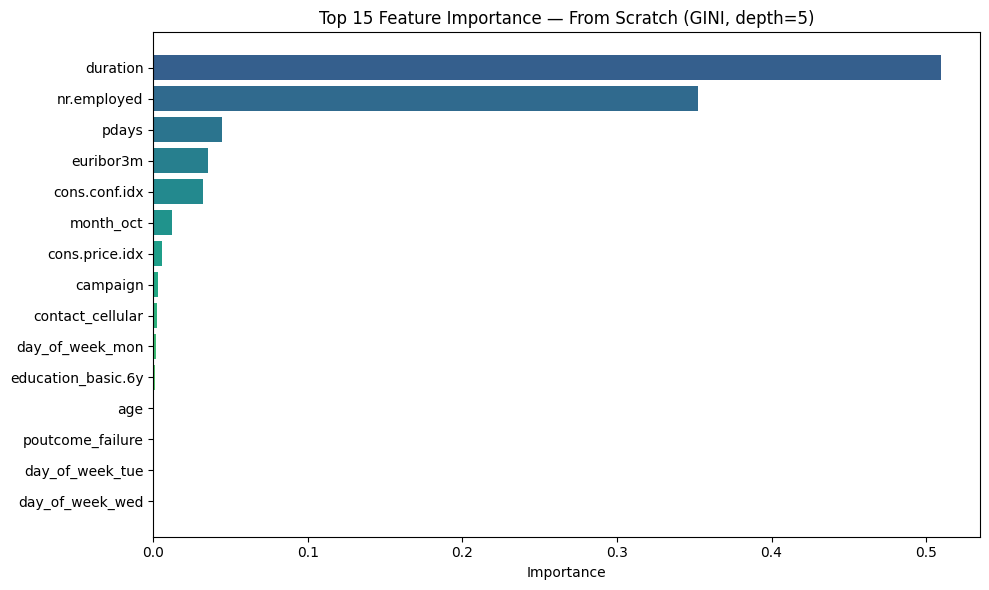

Top 10 Features:
   1. duration                       importance=0.5094
   2. nr.employed                    importance=0.3525
   3. pdays                          importance=0.0445
   4. euribor3m                      importance=0.0357
   5. cons.conf.idx                  importance=0.0318
   6. month_oct                      importance=0.0122
   7. cons.price.idx                 importance=0.0055
   8. campaign                       importance=0.0027
   9. contact_cellular               importance=0.0024
  10. day_of_week_mon                importance=0.0016


In [12]:
# Feature Importance (best model)
fig = plot_feature_importance(
    feature_names, dt_gini.feature_importances_,
    top_n=15, title="Top 15 Feature Importance — From Scratch (GINI, depth=5)"
)
plt.savefig("report/fig_scratch_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top 10
print("Top 10 Features:")
indices = np.argsort(dt_gini.feature_importances_)[::-1][:10]
for rank, i in enumerate(indices, 1):
    print(f"  {rank:2d}. {feature_names[i]:30s} importance={dt_gini.feature_importances_[i]:.4f}")


## 8. Post-Pruning (Reduced Error Pruning)


In [13]:
# Split validation set from training
from sklearn.model_selection import train_test_split as tts
X_tr, X_val, y_tr, y_val = tts(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Train unpruned tree
dt_unpruned = DecisionTreeClassifier(criterion="gini", max_depth=10)
dt_unpruned.fit(X_tr, y_tr, feature_names=feature_names)
acc_before = accuracy(y_test, dt_unpruned.predict(X_test))
depth_before = dt_unpruned.get_depth()
leaves_before = dt_unpruned.get_n_leaves()

print(f"Before pruning: acc={acc_before:.4f}, depth={depth_before}, leaves={leaves_before}")

# Prune
dt_unpruned.prune(X_val, y_val)
acc_after = accuracy(y_test, dt_unpruned.predict(X_test))
depth_after = dt_unpruned.get_depth()
leaves_after = dt_unpruned.get_n_leaves()

print(f"After pruning:  acc={acc_after:.4f}, depth={depth_after}, leaves={leaves_after}")
print(f"→ Pruning removed {leaves_before - leaves_after} leaves")
print(f"→ Accuracy change: {(acc_after - acc_before)*100:+.2f}%")


Before pruning: acc=0.9085, depth=10, leaves=422
After pruning:  acc=0.9156, depth=10, leaves=80
→ Pruning removed 342 leaves
→ Accuracy change: +0.72%


## 9. Lưu kết quả


## 8.5 Thí nghiệm: Loại bỏ biến Duration

Theo UCI documentation, biến `duration` chỉ biết **sau khi cuộc gọi kết thúc**.  
Nếu mục tiêu là dự đoán **trước cuộc gọi**, biến này phải bị loại bỏ.  
Chúng tôi chạy thêm thí nghiệm **không có duration** để so sánh.


In [14]:
# Thí nghiệm: loại bỏ duration
duration_idx = feature_names.index('duration') if 'duration' in feature_names else None

if duration_idx is not None:
    # Tạo dataset mới không có duration
    X_train_no_dur = np.delete(X_train, duration_idx, axis=1)
    X_test_no_dur = np.delete(X_test, duration_idx, axis=1)
    fn_no_dur = [f for f in feature_names if f != 'duration']

    dt_no_dur = DecisionTreeClassifier(criterion='gini', max_depth=5)
    dt_no_dur.fit(X_train_no_dur, y_train, feature_names=fn_no_dur)
    y_pred_no_dur = dt_no_dur.predict(X_test_no_dur)

    print('=== So sánh: Có Duration vs Không có Duration ===')
    print(f"{'Metric':<15s} {'Có duration':>15s} {'Không duration':>15s}")
    print('-' * 45)
    for name, fn in [('Accuracy', accuracy), ('Precision', precision), ('Recall', recall), ('F1', f1_score)]:
        if name == 'Accuracy':
            v1 = fn(y_test, y_pred_gini)
            v2 = fn(y_test, y_pred_no_dur)
        else:
            v1 = fn(y_test, y_pred_gini, 'yes')
            v2 = fn(y_test, y_pred_no_dur, 'yes')
        print(f'{name:<15s} {v1:>15.4f} {v2:>15.4f}')
    print()
    print('→ Nhận xét: Duration là feature rất mạnh.')
    print('  Loại bỏ sẽ giảm hiệu suất, nhưng kết quả thực tế hơn.')
    print('  Trong báo cáo, chúng tôi giữ duration cho benchmark analysis.')


=== So sánh: Có Duration vs Không có Duration ===
Metric              Có duration  Không duration
---------------------------------------------
Accuracy                 0.9144          0.9009
Precision                0.6534          0.6522
Recall                   0.5119          0.2586
F1                       0.5740          0.3704

→ Nhận xét: Duration là feature rất mạnh.
  Loại bỏ sẽ giảm hiệu suất, nhưng kết quả thực tế hơn.
  Trong báo cáo, chúng tôi giữ duration cho benchmark analysis.


## 8.6 Cross-Validation (5-fold) cho From Scratch


In [15]:
# 5-fold stratified CV cho from scratch
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accs = []
cv_f1s = []

print('=== 5-Fold Cross-Validation (From Scratch, GINI, depth=5) ===')
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    dt_cv = DecisionTreeClassifier(criterion='gini', max_depth=5)
    dt_cv.fit(X_tr, y_tr, feature_names=feature_names)
    y_cv_pred = dt_cv.predict(X_val)

    acc = accuracy(y_val, y_cv_pred)
    f1 = f1_score(y_val, y_cv_pred, 'yes')
    cv_accs.append(acc)
    cv_f1s.append(f1)
    print(f'  Fold {fold}: Accuracy={acc:.4f}, F1={f1:.4f}')

print(f'\nMean Accuracy: {np.mean(cv_accs):.4f} ± {np.std(cv_accs):.4f}')
print(f'Mean F1:       {np.mean(cv_f1s):.4f} ± {np.std(cv_f1s):.4f}')
print('\n→ Cross-validation xác nhận model ổn định trên nhiều fold.')


=== 5-Fold Cross-Validation (From Scratch, GINI, depth=5) ===
  Fold 1: Accuracy=0.9141, F1=0.5832
  Fold 2: Accuracy=0.9170, F1=0.5909
  Fold 3: Accuracy=0.9153, F1=0.5668
  Fold 4: Accuracy=0.9145, F1=0.5666
  Fold 5: Accuracy=0.9141, F1=0.5660

Mean Accuracy: 0.9150 ± 0.0011
Mean F1:       0.5747 ± 0.0104

→ Cross-validation xác nhận model ổn định trên nhiều fold.


In [16]:
# Lưu model và kết quả
results_scratch = {
    "gini_depth5": {"accuracy": accuracy(y_test, y_pred_gini),
                    "precision": precision(y_test, y_pred_gini, "yes"),
                    "recall": recall(y_test, y_pred_gini, "yes"),
                    "f1": f1_score(y_test, y_pred_gini, "yes"),
                    "depth": dt_gini.get_depth(),
                    "leaves": dt_gini.get_n_leaves()},
    "entropy_depth5": {"accuracy": accuracy(y_test, y_pred_entropy),
                       "precision": precision(y_test, y_pred_entropy, "yes"),
                       "recall": recall(y_test, y_pred_entropy, "yes"),
                       "f1": f1_score(y_test, y_pred_entropy, "yes"),
                       "depth": dt_entropy.get_depth(),
                       "leaves": dt_entropy.get_n_leaves()},
    "feature_importances": dict(zip(feature_names, dt_gini.feature_importances_)),
    "depth_analysis": results
}

with open("data/results_scratch.pkl", "wb") as f:
    pickle.dump(results_scratch, f)
print("✅ Kết quả from scratch đã lưu tại: data/results_scratch.pkl")


✅ Kết quả from scratch đã lưu tại: data/results_scratch.pkl
